# Exercise 4 Feature Engineering

In [1]:
#Imports
import gymnasium
import skyscraper
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

In [2]:
#Creating env for visualizing
env = gymnasium.make('MountainCar-v0', max_episode_steps = 1000) 
print("States:", env.observation_space)
print("Action:", env.action_space)

States: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action: Discrete(3)


As you can see above the data is continous and is not good for 

## 1. Discretization step

In [3]:
#Discretization and preprocessing
def state_discretization(state, env, bins):
    """make state deiscrete, not continuous - Q-learning needs this format"""
    low = env.observation_space.low
    high = env.observation_space.high

    #normalize the state to a value between 0 and 1
    ratio = (state-low) / (high-low)

    #scale to n of bins, whole number
    discrete = (ratio * (np.array(bins) - 1)).astype(int)

    #bins have to be inside valid limits
    discrete = np.clip(discrete, 0, np.array(bins)-1)

    return tuple(discrete)

#### Q-learning function

In [4]:
def qlearning(bins, episodes=3000):
    """train q-learning agent to drive the mountaincar, can choose bins and n episodes"""
    
    #creating env new every run for reproducability
    env = gymnasium.make('MountainCar-v0', max_episode_steps = 1000)

    #create Q-table with zeroes because the agent.knows = jonsnow.knows
    q_table = np.zeros(bins + (env.action_space.n,))

    #setting learning parameters
    learning_rate = 0.1      #alpha
    discount_factor = 0.95   #gamma
    exploration_rate = 1   #epsilon
    min_exploration_rate = 0.01
    exploration_decay_rate = 0.99

    rewards = [] #stores total reward from each episode -> for visualization etc

    #looop
    for ep in range(episodes):
        #init variables 
        total_reward = 0
        done = False

        state,_ = env.reset() #clean slate every episode
        
        st = state_discretization(state, env, bins) #convert current state into bins

        while not done:
            #epsilon greedy 
            if np.random.random () < exploration_rate:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[st])

            next_state, reward, goal_end, step_end,_ = env.step(action)

            #either goal is reached or step limit is reached
            done = goal_end or step_end

            #convert next state into bins
            ns = state_discretization(next_state, env, bins)

            #update Q-table
            q_table[st][action] += learning_rate * (reward + discount_factor*np.max(q_table[ns]) - q_table[st][action])

            st = ns 
            total_reward += reward 
    
            

        rewards.append(total_reward)
        
        exploration_rate = max(min_exploration_rate, exploration_rate * exploration_decay_rate)
                       
    return np.mean(rewards[-500:]) #return average reward per episode, only use the last 500 episodes to get a more accurate performance measure 

## 2. Using a range of discretization steps and comparing

In [5]:
bin_range = [10, 15, 20, 25, 30]
# 25 combinations

results = {}

for a in bin_range:
    for b in bin_range:
        score = qlearning(bins = (a,b))

        results[(a,b)] = score

        print("Grid:", (a,b), "Average reward:", score)

Grid: (10, 10) Average reward: -300.626
Grid: (10, 15) Average reward: -162.976
Grid: (10, 20) Average reward: -190.268
Grid: (10, 25) Average reward: -230.006
Grid: (10, 30) Average reward: -231.46
Grid: (15, 10) Average reward: -278.142
Grid: (15, 15) Average reward: -226.608
Grid: (15, 20) Average reward: -204.618
Grid: (15, 25) Average reward: -188.574
Grid: (15, 30) Average reward: -201.928
Grid: (20, 10) Average reward: -230.326
Grid: (20, 15) Average reward: -156.158
Grid: (20, 20) Average reward: -177.312
Grid: (20, 25) Average reward: -168.786
Grid: (20, 30) Average reward: -171.986
Grid: (25, 10) Average reward: -276.972
Grid: (25, 15) Average reward: -203.576
Grid: (25, 20) Average reward: -186.026
Grid: (25, 25) Average reward: -194.012
Grid: (25, 30) Average reward: -190.102
Grid: (30, 10) Average reward: -296.206
Grid: (30, 15) Average reward: -220.298
Grid: (30, 20) Average reward: -199.908
Grid: (30, 25) Average reward: -196.276
Grid: (30, 30) Average reward: -224.3


### Plot results 

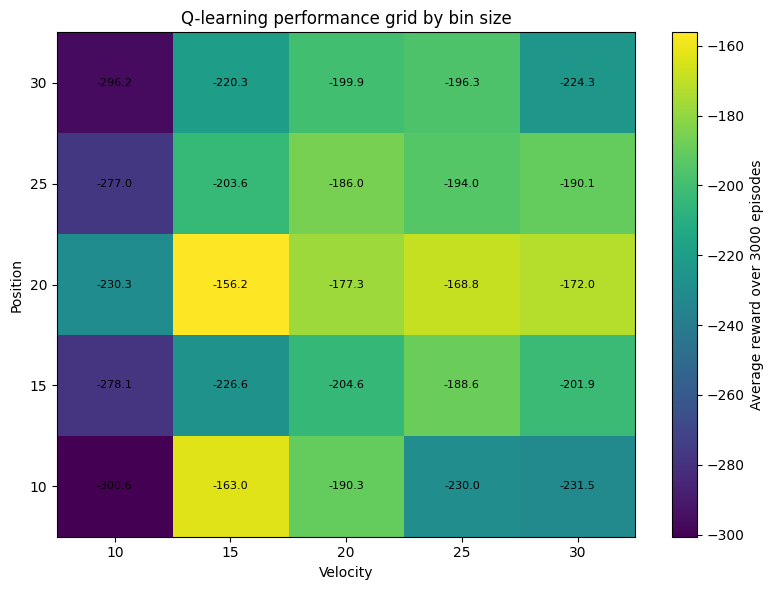

In [6]:
def plot_results(results, bin_range, episodes):
    score_matrix = np.array([
        [results[(a, b)] for b in bin_range]
        for a in bin_range
    ])

    plt.figure(figsize=(8, 6))
    im = plt.imshow(score_matrix, origin="lower", aspect="auto")
    plt.colorbar(im, label=f"Average reward over {episodes} episodes")

    plt.xticks(range(len(bin_range)), bin_range)
    plt.yticks(range(len(bin_range)), bin_range)

    plt.xlabel("Velocity")
    plt.ylabel("Position")
    plt.title("Q-learning performance grid by bin size")

    #put the score in the middle of each cell
    for i in range(len(bin_range)):
        for j in range(len(bin_range)):
            plt.text(j, i, f"{score_matrix[i, j]:.1f}",
                    ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_results(results, bin_range, episodes=3000)

#### Train best bins with more episodes 

In [8]:

better_bins = [(15,20),(20,20), (20,25)]
better_results = {}

for bins in better_bins:
    score = qlearning(bins = bins, episodes=10000)
    better_results[bins] = score
    print("Grid:", bins, "Average reward:", score)

Grid: (15, 20) Average reward: -180.544
Grid: (20, 20) Average reward: -154.376
Grid: (20, 25) Average reward: -163.388


# Exercise 5 Planning

In [ ]:
data = np.loadtxt("powered_flight.txt", dtype=int)

print("Shape of data:", data.shape)
print("First 5 rows:\n", data[:5])

Shape of data: (909, 6)
First 5 rows:
 [[18 17  1  0 17 13]
 [ 4 61  1  0  4 57]
 [12 20  2  0 11 23]
 [17 10  2  0 19 12]
 [ 8 15  1  0  9 12]]


In [ ]:
# columns 0,1,4,5 are row/column indices -> convert from 1-indexed to 0-indexed
transitions = data.copy()
transitions[:, 0] -= 1   # i
transitions[:, 1] -= 1   # j
transitions[:, 4] -= 1   # i_next
transitions[:, 5] -= 1   # j_next

# map file actions to real actions from the task description
# assuming: 1 -> -3, 2 -> +3
action_map = {
    1: -3,
    2: +3
}

for row in transitions:
    row[2] = action_map[row[2]]

print("Unique actions in processed data:", sorted(set(transitions[:, 2])))
print(transitions[:5])

Unique actions in processed data: [np.int64(-3), np.int64(3)]
[[17 16 -3  0 16 12]
 [ 3 60 -3  0  3 56]
 [11 19  3  0 10 22]
 [16  9  3  0 18 11]
 [ 7 14 -3  0  8 11]]


In [ ]:
transition_counts = defaultdict(lambda: defaultdict(int))
reward_sums = defaultdict(float)
reward_counts = defaultdict(int)

for row in transitions:
    i, j, a, r, i_next, j_next = row

    s = (int(i), int(j))
    s_next = (int(i_next), int(j_next))
    a = int(a)

    sa = (s, a)

    transition_counts[sa][s_next] += 1
    reward_sums[sa] += r
    reward_counts[sa] += 1

T_hat = {}
R_hat = {}

for sa, next_states in transition_counts.items():
    total = sum(next_states.values())

    T_hat[sa] = {
        s_next: count / total
        for s_next, count in next_states.items()
    }

    R_hat[sa] = reward_sums[sa] / reward_counts[sa]

print("Observed state-action pairs:", len(T_hat))

Observed state-action pairs: 909


In [ ]:
def sample_from_model(state, action):
    sa = (state, action)

    if sa not in T_hat:
        return 0.0, None

    next_states = list(T_hat[sa].keys())
    probs = list(T_hat[sa].values())

    next_state = random.choices(next_states, weights=probs, k=1)[0]
    reward = R_hat[sa]

    return reward, next_state


def available_actions(state):
    acts = []
    for (s, a) in T_hat.keys():
        if s == state:
            acts.append(a)
    return acts

In [ ]:
def dyna_q(transitions, planning_steps=20, alpha=0.1, gamma=0.95, epochs=20):
    """
    Tabular Dyna-Q using:
    - real experience from the dataset
    - imagined experience sampled from the learned model
    """

    states = set()
    actions = set()

    for row in transitions:
        i, j, a, r, i_next, j_next = row
        states.add((int(i), int(j)))
        states.add((int(i_next), int(j_next)))
        actions.add(int(a))

    states = sorted(states)
    actions = sorted(actions)   # should now be [-3, +3]

    Q = {(s, a): 0.0 for s in states for a in actions}

    model = {}
    rewards_per_epoch = []

    for ep in range(epochs):
        total_reward = 0

        rows = transitions.copy()
        np.random.shuffle(rows)

        for row in rows:
            i, j, a, r, i_next, j_next = row

            s = (int(i), int(j))
            a = int(a)
            r = float(r)
            s_next = (int(i_next), int(j_next))

            # real Q-learning update
            next_acts = available_actions(s_next)
            if len(next_acts) == 0:
                max_next_q = 0.0
            else:
                max_next_q = max(Q[(s_next, a2)] for a2 in next_acts)

            Q[(s, a)] = Q[(s, a)] + alpha * (r + gamma * max_next_q - Q[(s, a)])

            # update model memory
            model[(s, a)] = (r, s_next)

            total_reward += r

            # planning updates
            if len(model) > 0:
                model_keys = list(model.keys())

                for _ in range(planning_steps):
                    s_plan, a_plan = random.choice(model_keys)
                    r_plan, s_next_plan = model[(s_plan, a_plan)]

                    next_acts_plan = available_actions(s_next_plan)
                    if len(next_acts_plan) == 0:
                        max_next_q_plan = 0.0
                    else:
                        max_next_q_plan = max(Q[(s_next_plan, a2)] for a2 in next_acts_plan)

                    Q[(s_plan, a_plan)] = Q[(s_plan, a_plan)] + alpha * (
                        r_plan + gamma * max_next_q_plan - Q[(s_plan, a_plan)]
                    )

        rewards_per_epoch.append(total_reward)

    return Q, rewards_per_epoch

In [ ]:
Q, rewards_per_epoch = dyna_q(
    transitions,
    planning_steps=20,
    alpha=0.1,
    gamma=0.95,
    epochs=30
)

print("Training done.")
print("Reward collected per epoch:", rewards_per_epoch[-5:])

Training done.
Reward collected per epoch: [1.0, 1.0, 1.0, 1.0, 1.0]


In [ ]:
def simulate_policy(policy, start_state, max_steps=200):
    state = start_state
    path = [state]

    for _ in range(max_steps):
        if state not in policy:
            print("No action defined for state:", state)
            break

        action = policy[state]
        reward, next_state = sample_from_model(state, action)

        if next_state is None:
            print("No transition in model for:", (state, action))
            break

        path.append(next_state)
        state = next_state

        if reward == 1:
            print("Goal reached!")
            break

    return path

In [ ]:
start_state = (13, 5)
goal_state = (14, 54)

path = simulate_policy(policy, start_state)

print("Trajectory length:", len(path))
print("Final state:", path[-1])
print(path)

Goal reached!
Trajectory length: 16
Final state: (14, 54)
[(13, 5), (13, 1), (10, 19), (8, 23), (7, 26), (2, 29), (3, 34), (4, 36), (5, 38), (6, 34), (7, 36), (8, 55), (9, 58), (10, 61), (13, 58), (14, 54)]


skyline shape: (32, 64)
horizontal wind shape: (32, 64)
vertical wind shape: (32, 64)
Goal reached!


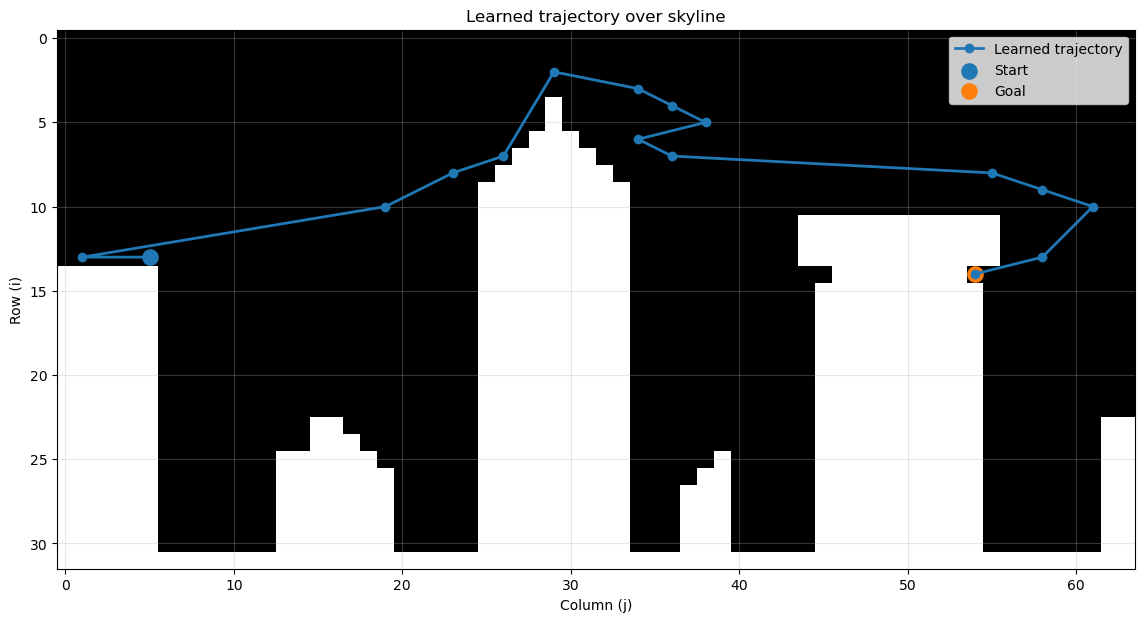

In [ ]:
skyline = np.loadtxt("skyscraper/envs/skyline.txt", dtype=int)
horizontal_wind = np.loadtxt("skyscraper/envs/horizontal_wind.txt", dtype=int)
vertical_wind = np.loadtxt("skyscraper/envs/vertical_wind.txt", dtype=int)

start_state = (13, 5)
goal_state = (14, 54)

path = simulate_policy(policy, start_state)
path_array = np.array(path)

plt.figure(figsize=(14, 7))

# plot skyline: buildings/obstacles
plt.imshow(skyline, cmap="Greys", origin="upper")

# overlay trajectory
plt.plot(path_array[:, 1], path_array[:, 0], marker="o", linewidth=2, label="Learned trajectory")

# mark start and goal
plt.scatter(start_state[1], start_state[0], s=120, label="Start")
plt.scatter(goal_state[1], goal_state[0], s=120, label="Goal")

plt.title("Learned trajectory over skyline")
plt.xlabel("Column (j)")
plt.ylabel("Row (i)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
## Running Dyna for different numbers of simulations

planning_range = [0, 1, 5, 10, 20, 50, 100]

results = {}

for p in planning_range:
    Q, rewards_per_epoch = dyna_q(
        transitions,
        planning_steps=p,
        alpha=0.1,
        gamma=0.95,
        epochs=30
    )

    policy = greedy_policy(Q)
    start_state = (13, 5)

    if start_state in policy:
        best_action = policy[start_state]
    else:
        best_action = None

    results[p] = {
        "Q": Q,
        "policy": policy,
        "rewards_per_epoch": rewards_per_epoch,
        "final_reward": rewards_per_epoch[-1],
        "avg_reward_last_5": np.mean(rewards_per_epoch[-5:]),
        "start_action": best_action
    }

    print(
        f"planning_steps = {p:3} | "
        f"final reward = {results[p]['final_reward']:.2f} | "
        f"avg last 5 = {results[p]['avg_reward_last_5']:.2f} | "
        f"start action = {results[p]['start_action']}"
    )

planning_steps =   0 | final reward = 1.00 | avg last 5 = 1.00 | start action = -3
planning_steps =   1 | final reward = 1.00 | avg last 5 = 1.00 | start action = -3
planning_steps =   5 | final reward = 1.00 | avg last 5 = 1.00 | start action = 3
planning_steps =  10 | final reward = 1.00 | avg last 5 = 1.00 | start action = 3
planning_steps =  20 | final reward = 1.00 | avg last 5 = 1.00 | start action = -3
planning_steps =  50 | final reward = 1.00 | avg last 5 = 1.00 | start action = -3
planning_steps = 100 | final reward = 1.00 | avg last 5 = 1.00 | start action = -3


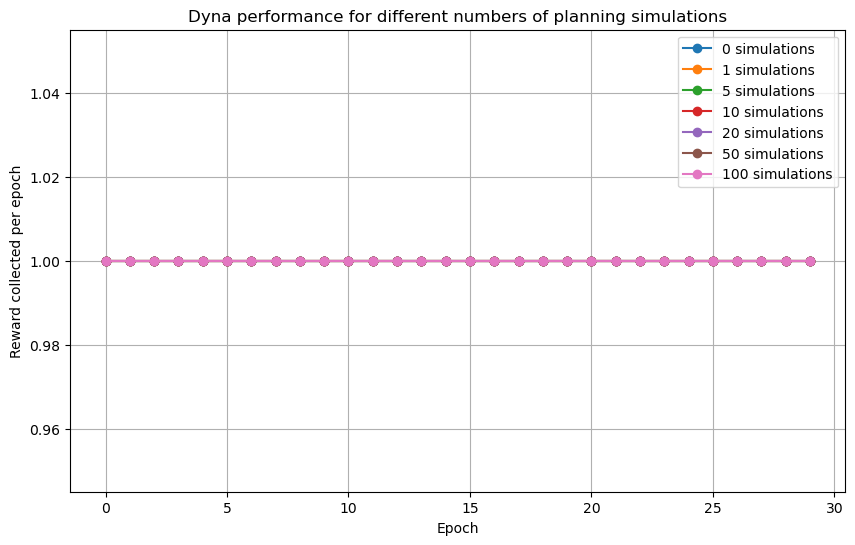

In [ ]:
## Plot learning curves

plt.figure(figsize=(10, 6))

for p in planning_range:
    plt.plot(results[p]["rewards_per_epoch"], marker='o', label=f"{p} simulations")

plt.title("Dyna performance for different numbers of planning simulations")
plt.xlabel("Epoch")
plt.ylabel("Reward collected per epoch")
plt.legend()
plt.grid(True)
plt.show()

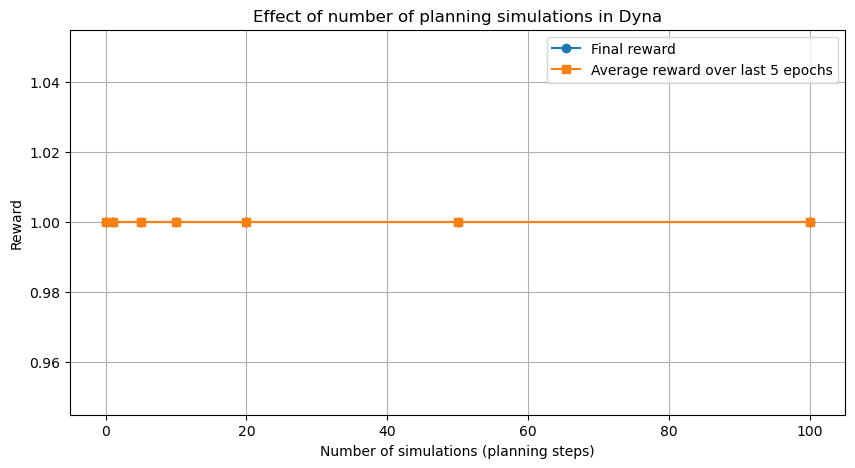

In [ ]:
## Compare performance

final_rewards = [results[p]["final_reward"] for p in planning_range]
avg_last_5 = [results[p]["avg_reward_last_5"] for p in planning_range]

plt.figure(figsize=(10, 5))
plt.plot(planning_range, final_rewards, marker='o', label="Final reward")
plt.plot(planning_range, avg_last_5, marker='s', label="Average reward over last 5 epochs")

plt.title("Effect of number of planning simulations in Dyna")
plt.xlabel("Number of simulations (planning steps)")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()

Goal reached!
Goal reached!
Goal reached!
Goal reached!
Goal reached!
Goal reached!
Goal reached!


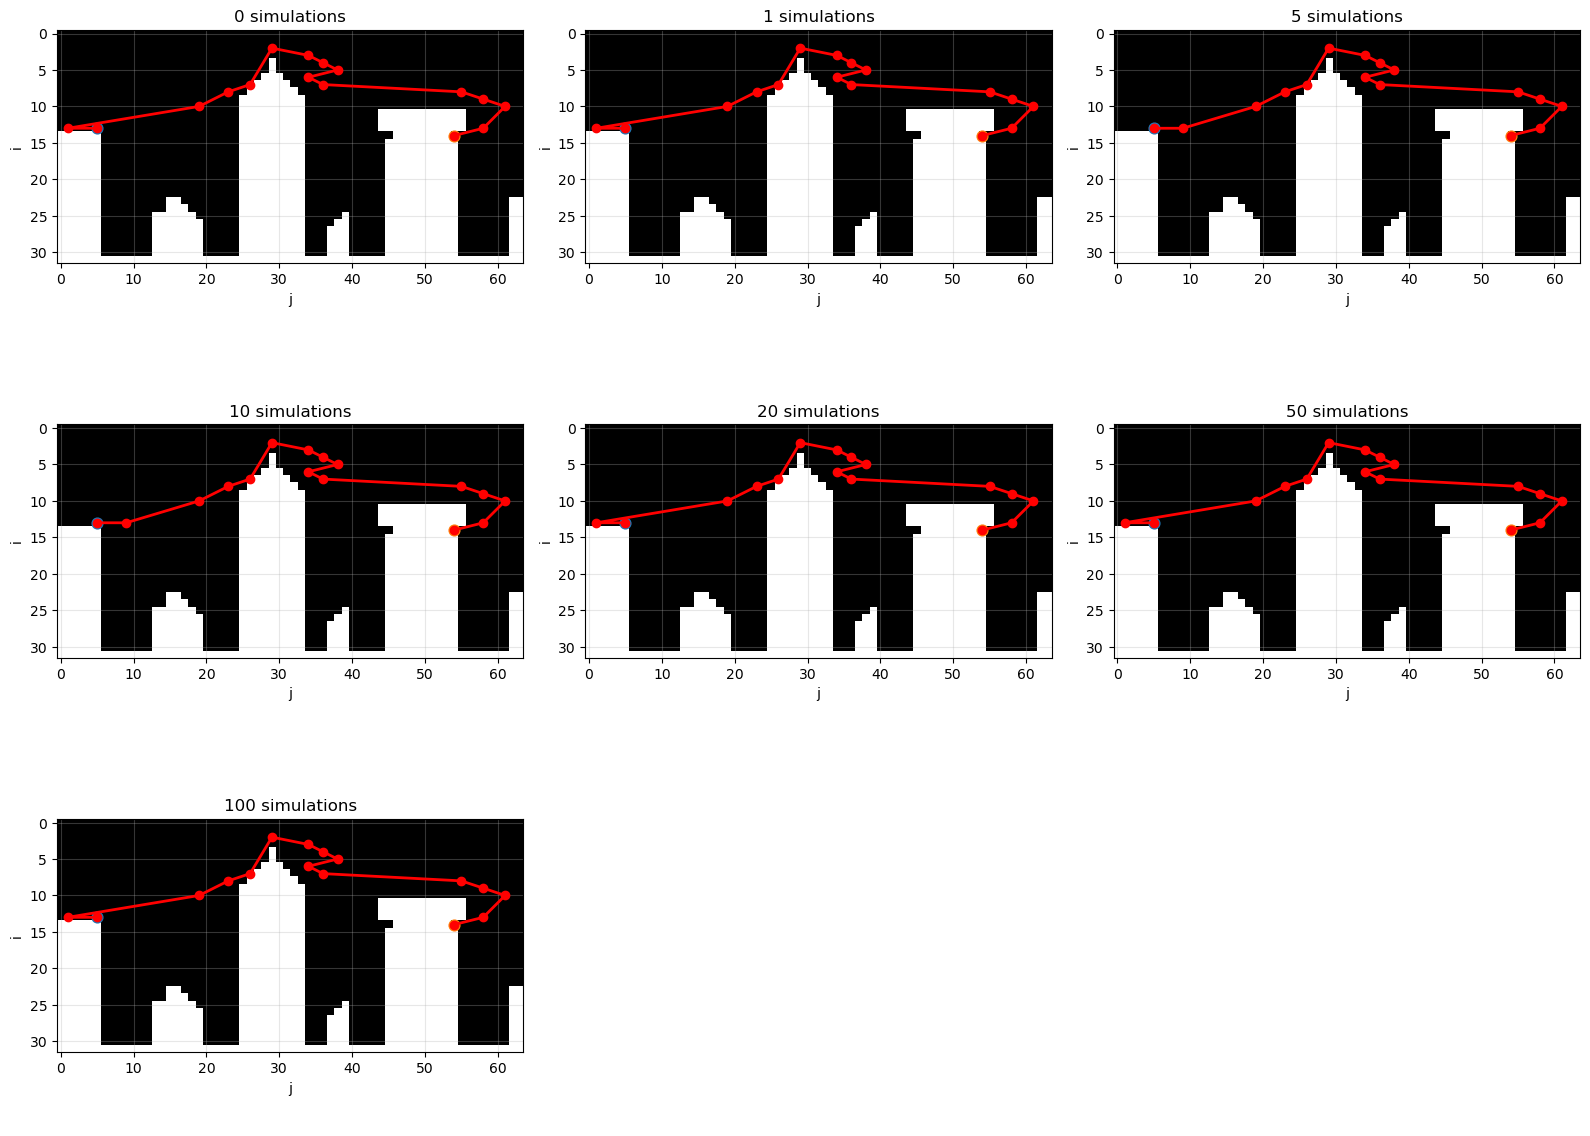

In [ ]:
## Compare trajectories

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, p in enumerate(planning_range):
    ax = axes[idx]
    
    policy = results[p]["policy"]
    path = simulate_policy(policy, (13, 5))
    path_array = np.array(path)

    ax.imshow(skyline, cmap="Greys", origin="upper")
    ax.plot(
        path_array[:, 1],
        path_array[:, 0],
        marker='o',
        linewidth=2,
        color='red'
    )

    ax.scatter(5, 13, s=60)
    ax.scatter(54, 14, s=60)

    ax.set_title(f"{p} simulations")
    ax.set_xlabel("j")
    ax.set_ylabel("i")
    ax.grid(True, alpha=0.3)

# hide unused subplot if there is one
for k in range(len(planning_range), len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
trajectory_info = {}

for p in planning_range:
    policy = results[p]["policy"]
    path = simulate_policy(policy, (13, 5))
    
    trajectory_info[p] = {
        "path_length": len(path),
        "final_state": path[-1],
        "reached_goal": path[-1] == (14, 54)
    }

for p in planning_range:
    info = trajectory_info[p]
    print(
        f"{p:3} simulations | "
        f"path length = {info['path_length']:3} | "
        f"final state = {info['final_state']} | "
        f"goal reached = {info['reached_goal']}"
    )

Goal reached!
Goal reached!
Goal reached!
Goal reached!
Goal reached!
Goal reached!
Goal reached!
  0 simulations | path length =  16 | final state = (14, 54) | goal reached = True
  1 simulations | path length =  16 | final state = (14, 54) | goal reached = True
  5 simulations | path length =  16 | final state = (14, 54) | goal reached = True
 10 simulations | path length =  16 | final state = (14, 54) | goal reached = True
 20 simulations | path length =  16 | final state = (14, 54) | goal reached = True
 50 simulations | path length =  16 | final state = (14, 54) | goal reached = True
100 simulations | path length =  16 | final state = (14, 54) | goal reached = True
